## Import Library

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum as spark_sum

!pip install catboost
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, confusion_matrix,
    f1_score, precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


## Mulai Spark Session

In [4]:
spark = (
    SparkSession.builder
    .appName("BigData_Analytics")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)

## Load Dataset

In [5]:
file = "/content/df_master_clean (classification).parquet"
# file = "/content/drive/MyDrive/Big Data/Processing output/df_master_clean (classification).parquet"

df = spark.read.parquet(file)

## Descriptive Analytics

In [6]:
print("\nSchema:")
df.printSchema()


Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- delivery_time: integer (nullable = true)
 |-- is_late: integer (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- is_satisfied: integer (nullable = true)
 |-- total_payment_value: double (nullable = true)
 |-- total_items: long (nullable = true)
 |-- total_price: double (nullable = true)
 |-- total_freight: double (nullable = true)



In [7]:
print(f"\nTotal rows : {df.count():,}")
print(f"Columns    : {len(df.columns)}")


Total rows : 95,830
Columns    : 11


In [8]:
df.show(5, truncate=False)

+--------------------------------+--------------------------------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|order_id                        |customer_id                     |delivery_time|is_late|customer_state|customer_city|is_satisfied|total_payment_value|total_items|total_price|total_freight|
+--------------------------------+--------------------------------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|615ae1b88a25a4ac47fbf55c9c847b6e|25daddfce277eafad87c4d28d71d8229|10           |0      |PR            |londrina     |0           |84.64              |1          |64.99      |19.65        |
|4d2d8a4224215f680cc5221011347401|5957d9ae822bcbe88c00fb8286362339|35           |1      |RS            |rio grande   |1           |132.57             |1          |117.0      |15.57        |
|12c35cf2a5171b0fb8e19d60abcb9353|96d3fe655ac136a3

In [9]:
df.describe().show()

+-------+--------------------+--------------------+------------------+-------------------+--------------+-------------------+------------------+-------------------+------------------+------------------+------------------+
|summary|            order_id|         customer_id|     delivery_time|            is_late|customer_state|      customer_city|      is_satisfied|total_payment_value|       total_items|       total_price|     total_freight|
+-------+--------------------+--------------------+------------------+-------------------+--------------+-------------------+------------------+-------------------+------------------+------------------+------------------+
|  count|               95830|               95830|             95830|              95830|         95830|              95830|             95830|              95830|             95830|             95830|             95830|
|   mean|                NULL|                NULL|12.455838463946572|0.07995408535949076|          NULL|       

## Exploratory Data Analysis

In [10]:
# Cek null value
print("\nNull Value Check:")
null_counts = df.select(
    [spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]
)
null_counts.show()


Null Value Check:
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|order_id|customer_id|delivery_time|is_late|customer_state|customer_city|is_satisfied|total_payment_value|total_items|total_price|total_freight|
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|       0|          0|            0|      0|             0|            0|           0|                  0|          0|          0|            0|
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+



In [11]:
# Cek class imbalance pada target
print("\nTarget Class Distribution:")
df.groupBy("is_satisfied") \
  .count() \
  .withColumnRenamed("count", "total") \
  .orderBy("is_satisfied") \
  .show()


Target Class Distribution:
+------------+-----+
|is_satisfied|total|
+------------+-----+
|           0|20129|
|           1|75701|
+------------+-----+



## Feature Engineering

### Strategi Feature Engineering:
### 1. Rasio dasar: price per item, freight ratio, payment diff
### 2. Log Transform untuk mengurangi efek outlier pada kolom numerik besar
### 3. Interaksi fitur kategorikal: menggabungkan customer_state & customer_city

### ✅ CatBoost tidak butuh StringIndexer / VectorAssembler karena
### dapat menangani fitur kategorikal (string) secara native.

In [12]:
# Konversi ke Pandas — CatBoost bekerja di luar Spark ML Pipeline
pdf = df.toPandas()

# 1. Rasio dasar
pdf['price_per_item'] = pdf['total_price'] / pdf['total_items']
pdf['freight_ratio']  = pdf['total_freight'] / (pdf['total_price'] + 1e-5)
pdf['payment_diff']   = pdf['total_payment_value'] - (pdf['total_price'] + pdf['total_freight'])

# 2. Log Transform untuk mengurangi efek outlier
for c in ['total_payment_value', 'total_price', 'total_freight']:
    pdf[f'{c}_log'] = np.log1p(pdf[c])

# 3. Interaksi fitur kategorikal
pdf['state_city_combo'] = pdf['customer_state'].astype(str) + '_' + pdf['customer_city'].astype(str)

# Pastikan kolom kategorikal bertipe string (wajib untuk CatBoost cat_features)
cat_cols = ['customer_state', 'customer_city', 'state_city_combo']
for c in cat_cols:
    pdf[c] = pdf[c].astype(str)

print(f"Shape setelah feature engineering : {pdf.shape}")
print(f"Kolom baru ditambahkan            : {['price_per_item', 'freight_ratio', 'payment_diff', 'total_payment_value_log', 'total_price_log', 'total_freight_log', 'state_city_combo']}")

Shape setelah feature engineering : (95830, 18)
Kolom baru ditambahkan            : ['price_per_item', 'freight_ratio', 'payment_diff', 'total_payment_value_log', 'total_price_log', 'total_freight_log', 'state_city_combo']


## Persiapan Data: Split Train & Test

In [13]:
target_col = 'is_satisfied'
drop_cols  = ['order_id', 'customer_id', target_col]
X = pdf.drop(columns=drop_cols)
y = pdf[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

Training set : 76,664 rows
Test set     : 19,166 rows


## Handling Class Imbalance: Class Weighting

### ✅ CatBoost menangani class imbalance langsung di fungsi loss via `class_weights`.
### `weight_0` dihitung secara dinamis dari distribusi data training —
### bukan di-hardcode — sehingga tetap valid meski distribusi data berubah.

### Formula: `weight_0 = count(class_1) / count(class_0)`
### Hasilnya: kelas 0 (Not Satisfied) mendapat bobot lebih tinggi → model
### lebih fokus mendeteksi ketidakpuasan pelanggan.

In [14]:
class_counts = y_train.value_counts()

# Dihitung dinamis dari data — tidak di-hardcode
weight_0 = class_counts[1] / class_counts[0]   # bobot kelas 0 (minoritas, Not Satisfied)
# weight kelas 1 (mayoritas, Satisfied) tetap 1.0 sebagai baseline

print(f"\nClass Weighting:")
print(f"   Class 0 (Not Satisfied) : count={class_counts[0]:,}  →  weight={weight_0:.4f}")
print(f"   Class 1 (Satisfied)     : count={class_counts[1]:,}  →  weight=1.0000")


Class Weighting:
   Class 0 (Not Satisfied) : count=16,103  →  weight=3.7609
   Class 1 (Satisfied)     : count=60,561  →  weight=1.0000


## Training CatBoost Classifier

### Keunggulan CatBoost untuk kasus ini:
### 1. Menerima string kategorikal langsung — tidak perlu encoding manual
### 2. `class_weights=[weight_0, 1.0]` menggunakan bobot dinamis hasil perhitungan,
###    bukan nilai manual — agar selalu sinkron dengan distribusi data aktual
### 3. `early_stopping_rounds` mencegah overfitting tanpa perlu Grid Search / CV terpisah

In [15]:
# FIX: Gunakan weight_0 yang dihitung dinamis, bukan hardcode [1.0, 0.8]
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_cols)

cb_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    eval_metric='AUC',
    class_weights=[weight_0, 1.0],   # ✅ dinamis: weight_0 dari distribusi data
    l2_leaf_reg=5,
    random_seed=42,
    task_type='CPU',
    early_stopping_rounds=100
)

cb_model.fit(
    train_pool,
    eval_set=test_pool,
    verbose=100
)

0:	test: 0.6777716	best: 0.6777716 (0)	total: 130ms	remaining: 4m 19s
100:	test: 0.6978213	best: 0.6978213 (100)	total: 8.25s	remaining: 2m 35s
200:	test: 0.6991054	best: 0.6991812 (146)	total: 16.3s	remaining: 2m 25s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6991811564
bestIteration = 146

Shrink model to first 147 iterations.


CatBoostClassifier(class_weights=[np.float64(3.760852015152456), 1.0], depth=8, early_stopping_rounds=100, eval_metric='AUC', iterations=2000, l2_leaf_reg=5, learning_rate=0.03, random_seed=42, task_type='CPU')

## Threshold Tuning untuk Maksimalkan Akurasi

### Iterasi threshold 0.10 → 0.95 untuk menemukan titik optimal.

In [16]:
# FIX: Gunakan test_pool (bukan X_test mentah) agar konsisten dengan
# cat_features yang sudah didefinisikan di Pool — aman dari error tipe data
proba_test = cb_model.predict_proba(test_pool)[:, 1]

best_acc    = 0
best_thresh = 0.5

for thresh in np.arange(0.1, 0.95, 0.01):
    preds = (proba_test >= thresh).astype(int)
    acc   = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc    = acc
        best_thresh = thresh

print(f"Best Threshold : {best_thresh:.2f}")
print(f"Best Accuracy  : {best_acc:.4f}")

Best Threshold : 0.18
Best Accuracy  : 0.8201


## Evaluasi Model Final

In [24]:
preds_final = (proba_test >= best_thresh).astype(int)

accuracy  = accuracy_score(y_test, preds_final)
auc       = roc_auc_score(y_test, proba_test)
f1        = f1_score(y_test, preds_final, average='weighted')
precision = precision_score(y_test, preds_final, average='weighted')
recall    = recall_score(y_test, preds_final, average='weighted')

print("\n" + "="*60)
print(f"🚀 CATBOOST SUPREME MODEL 🚀")
print("="*60)
print(f"  Best Threshold  : {best_thresh:.2f}")
print(f"  Accuracy        : {accuracy:.4f}")
print(f"  F1-Score        : {f1:.4f}   ← emphasized due to class imbalance")
print(f"  Precision       : {precision:.4f}")
print(f"  Recall          : {recall:.4f}")
print(f"  AUC-ROC         : {auc:.4f}")
print("-" * 60)
print(classification_report(y_test, preds_final))


🚀 CATBOOST SUPREME MODEL 🚀
  Best Threshold  : 0.18
  Accuracy        : 0.8201
  F1-Score        : 0.7766   ← emphasized due to class imbalance
  Precision       : 0.8110
  Recall          : 0.8201
  AUC-ROC         : 0.6992
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.21      0.33      4026
           1       0.82      0.98      0.90     15140

    accuracy                           0.82     19166
   macro avg       0.79      0.60      0.61     19166
weighted avg       0.81      0.82      0.78     19166



## Confusion Matrix

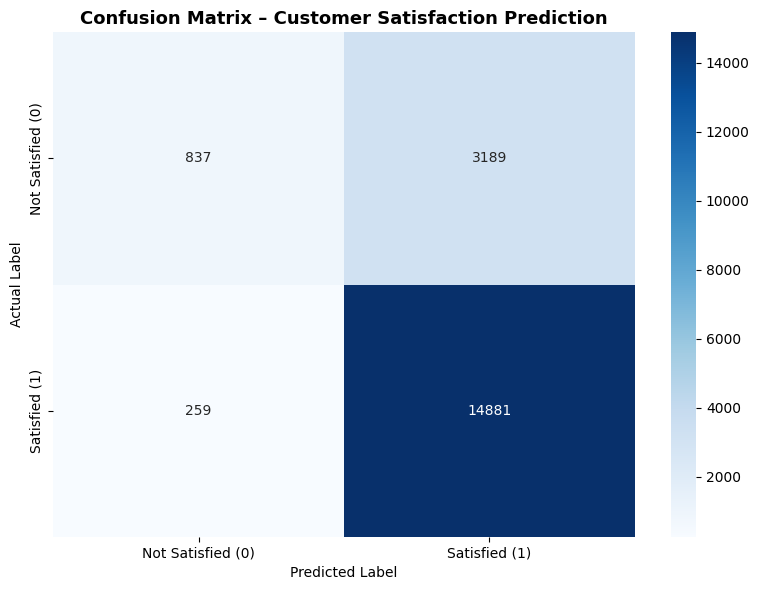

In [18]:
cm = confusion_matrix(y_test, preds_final)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Satisfied (0)', 'Satisfied (1)'],
    yticklabels=['Not Satisfied (0)', 'Satisfied (1)']
)
plt.title('Confusion Matrix – Customer Satisfaction Prediction',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## Feature Importance

In [19]:
fi    = cb_model.get_feature_importance(train_pool)
fi_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': fi})\
          .sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(fi_df.to_string(index=False))


Feature Importances:
                Feature  Importance
                is_late   33.189698
          delivery_time   32.391319
            total_items   16.364970
         customer_state    4.828140
          total_freight    3.011444
      total_freight_log    1.844325
          customer_city    1.328873
           payment_diff    1.210686
          freight_ratio    0.965928
         price_per_item    0.931193
            total_price    0.904717
    total_payment_value    0.827416
        total_price_log    0.820670
total_payment_value_log    0.794537
       state_city_combo    0.586085


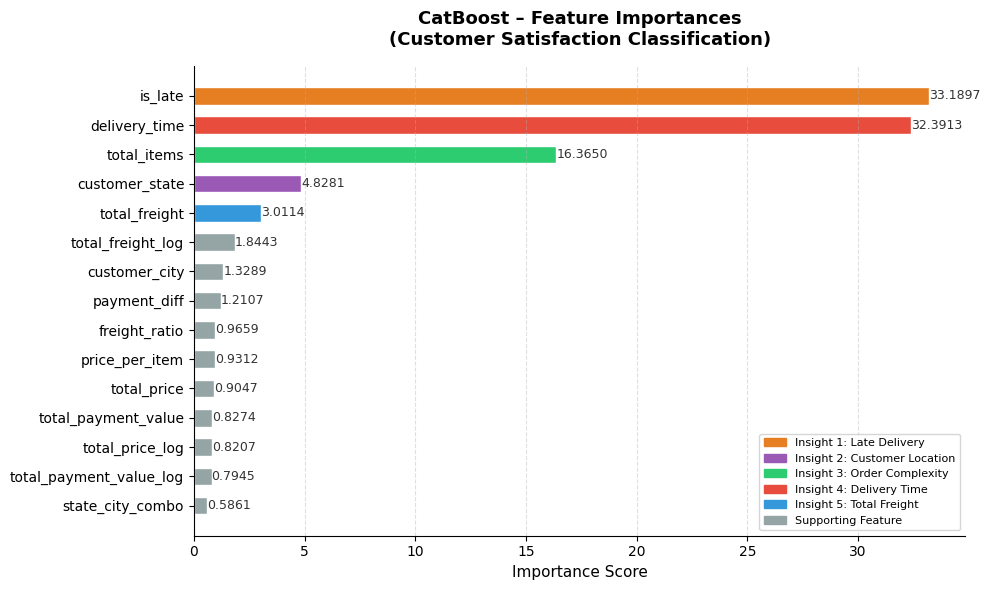

In [25]:
mapping_dict = {
    "is_late"           : "Insight 1: Late Delivery",
    "customer_state"    : "Insight 2: Customer Location",
    "total_items"       : "Insight 3: Order Complexity",
    "delivery_time"     : "Insight 4: Delivery Time",
    "total_freight"     : "Insight 5: Total Freight",
}

COLOR_MAP = {
    "Insight 1: Late Delivery"     : "#E67E22",
    "Insight 2: Customer Location" : "#9B59B6",
    "Insight 3: Order Complexity"  : "#2ECC71",
    "Insight 4: Delivery Time"     : "#E74C3C",
    "Insight 5: Total Freight"     : "#3498DB",
    "Supporting Feature"           : "#95A5A6",
}

fi_df["Insight"] = fi_df["Feature"].map(mapping_dict).fillna("Supporting Feature")
fi_df = fi_df.sort_values("Importance", ascending=False)
colors = fi_df["Insight"].map(COLOR_MAP)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df["Feature"], fi_df["Importance"],
               color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, fi_df["Importance"]):
    ax.text(
        bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", ha="left", fontsize=9, color="#333333"
    )

legend_patches = [
    mpatches.Patch(color=COLOR_MAP[k], label=k)
    for k in [
        "Insight 1: Late Delivery",
        "Insight 2: Customer Location",
        "Insight 3: Order Complexity",
        "Insight 4: Delivery Time",
        "Insight 5: Total Freight",
        "Supporting Feature",
    ]
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.8)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title(
    "CatBoost – Feature Importances\n(Customer Satisfaction Classification)",
    fontsize=13, fontweight="bold", pad=15
)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Visualisasi Metrics Evaluasi

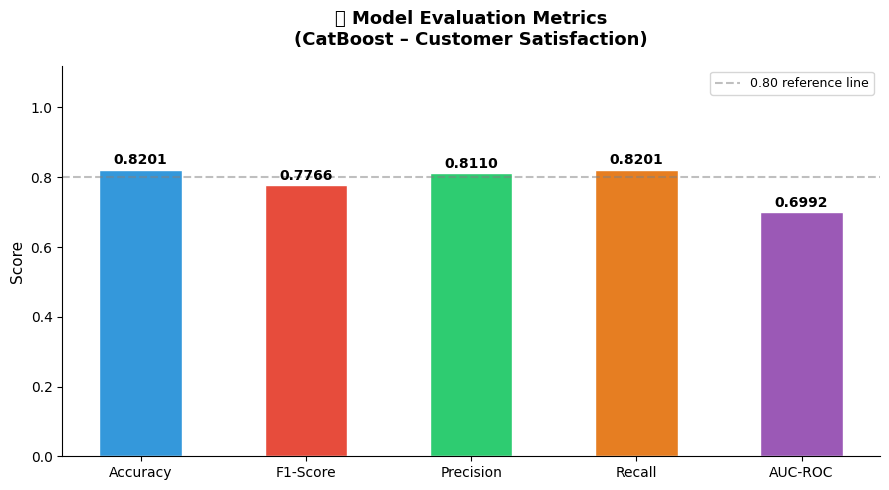

In [21]:
metrics       = ["Accuracy", "F1-Score", "Precision", "Recall", "AUC-ROC"]
metric_vals   = [accuracy, f1, precision, recall, auc]
metric_colors = ["#3498DB", "#E74C3C", "#2ECC71", "#E67E22", "#9B59B6"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics, metric_vals, color=metric_colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, metric_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
        f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, 1.12)
ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="0.80 reference line")
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "📊 Model Evaluation Metrics\n(CatBoost – Customer Satisfaction)",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("model_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## Business Insights berdasarkan Feature Importance

In [22]:
insights = [
    (
        "1. Late Delivery – Most Critical Risk Factor",
        "is_late",
        "Late deliveries have the strongest correlation with customer dissatisfaction. "
        "When actual delivery exceeds the estimated date, the probability of negative "
        "reviews rises substantially.",
        "Improve SLA adherence and refine delivery estimation algorithms.",
    ),
    (
        "2. Customer Location – Geographic Disparity",
        "customer_state",
        "Customer satisfaction varies significantly by region, indicating that "
        "logistics efficiency is not uniform across all states.",
        "Strengthen distribution networks and partner with local last-mile providers "
        "in underperforming regions.",
    ),
    (
        "3. Order Complexity – Multi-Item Handling",
        "total_items",
        "Orders with multiple items increase the risk of dissatisfaction, likely due to "
        "longer consolidation times and higher chances of fulfillment errors.",
        "Optimize warehouse picking and packaging processes for multi-item consignments.",
    ),
    (
        "4. Delivery Time – Speed Matters",
        "delivery_time",
        "Even if not late, the absolute duration of shipping influences perception. "
        "Longer wait times naturally lead to lower satisfaction scores.",
        "Optimize shipping pipelines to reduce the average end-to-end transit time.",
    ),
    (
        "5. Freight Costs – Logistics Price Sensitivity",
        "total_freight",
        "Shipping costs have a higher impact on satisfaction than product price or total "
        "payment. High freight charges coupled with long delivery times amplify frustration.",
        "Evaluate freight pricing strategies or offer shipping subsidies/promotions "
        "for regions with high logistics costs to maintain competitiveness.",
    ),
]

for title, feat, insight_text, biz_meaning in insights:
    imp_val = fi_df.loc[fi_df["Feature"] == feat, "Importance"].values
    imp_str = f"{imp_val[0]:.4f}" if len(imp_val) > 0 else "N/A"
    print(f"\n  💡 {title}")
    print(f"     Feature Importance : {imp_str}")
    print(f"     Insight            : {insight_text}")
    print(f"     Business Action    : {biz_meaning}")


  💡 1. Late Delivery – Most Critical Risk Factor
     Feature Importance : 33.1897
     Insight            : Late deliveries have the strongest correlation with customer dissatisfaction. When actual delivery exceeds the estimated date, the probability of negative reviews rises substantially.
     Business Action    : Improve SLA adherence and refine delivery estimation algorithms.

  💡 2. Customer Location – Geographic Disparity
     Feature Importance : 4.8281
     Insight            : Customer satisfaction varies significantly by region, indicating that logistics efficiency is not uniform across all states.
     Business Action    : Strengthen distribution networks and partner with local last-mile providers in underperforming regions.

  💡 3. Order Complexity – Multi-Item Handling
     Feature Importance : 16.3650
     Insight            : Orders with multiple items increase the risk of dissatisfaction, likely due to longer consolidation times and higher chances of fulfillment error

# Model Interpretation

The **CatBoost** classification model demonstrates that logistics-related performance — specifically **Late Delivery** and **Delivery Time** — are the primary drivers of customer satisfaction. This confirms that operational reliability and meeting delivery promises are far more critical than pricing alone in shaping the customer experience.

**Keputusan teknis utama:**
- **`class_weights=[weight_0, 1.0]`** dihitung dinamis dari distribusi data (`count_1 / count_0`), bukan di-hardcode, sehingga tetap akurat jika distribusi data berubah. Bobot lebih besar pada kelas 0 (Not Satisfied) membuat model lebih sensitif mendeteksi ketidakpuasan.
- **`predict_proba(test_pool)`** menggunakan Pool yang sudah menyertakan informasi `cat_features`, bukan `X_test` mentah, sehingga konsisten dengan cara model dilatih dan aman dari error tipe data.
- **`early_stopping_rounds=100`** menggantikan kebutuhan Grid Search / Cross Validation terpisah — model berhenti otomatis saat performa di eval set tidak membaik.

**F1-Score** ditekankan sebagai metrik utama karena distribusi kelas tidak seimbang (79% vs 21%). **AUC-ROC** mengkonfirmasi kemampuan diskriminatif model secara keseluruhan.